<div dir="rtl" align="right">

## بررسی اولیه فایل‌های داده

در این مرحله، فایل‌های موجود در مسیر داده، اندازه فایل‌ها، نام ستون‌ها، نوع داده ستون‌ها و چند نمونه از هر فایل CSV بررسی می‌شوند. نتیجه بررسی برای اشتراک‌گذاری و تحلیل بعدی در یک فایل Markdown ذخیره می‌شود.

</div>

In [2]:
from pathlib import Path

import pandas as pd
from IPython.display import display

# مسیرهای مورد استفاده
DATA_DIR = Path("/home/ali/datasets/AI_Project2/nlp")
REPORT_DIR = Path("/home/ali/GoogleDrive/AI_Project2/outputs/nlp")

# ستون‌های احتمالی موردنیاز برای سؤال‌های ۳، ۵ و ۶
REQUIRED_COLUMNS = [
    "overall",
    "vote",
    "reviewerID",
    "reviewerName",
    "asin",
    "Asin",
    "brand",
    "title",
]

# انتخاب نام فایل بدون بازنویسی خروجی قبلی
base_report_path = REPORT_DIR / "nlp_data_inspection.md"
report_path = base_report_path
file_number = 2

while report_path.exists():
    report_path = REPORT_DIR / f"nlp_data_inspection_{file_number}.md"
    file_number += 1

# شناسایی فایل‌های داده
allowed_suffixes = {".csv", ".json", ".jsonl", ".parquet", ".feather"}

data_files = sorted(
    path
    for path in DATA_DIR.iterdir()
    if path.is_file() and path.suffix.lower() in allowed_suffixes
)

report_lines = [
    "# گزارش بررسی اولیه داده‌های NLP",
    "",
    f"- مسیر داده‌ها: `{DATA_DIR}`",
    f"- تعداد فایل‌های شناسایی‌شده: `{len(data_files)}`",
    "",
    "## فهرست فایل‌ها",
    "",
]

# ثبت مشخصات فایل‌ها
for path in data_files:
    size_mb = path.stat().st_size / (1024 ** 2)
    report_lines.append(
        f"- `{path.name}` — `{size_mb:,.2f} MB` — `{path.suffix.lower()}`"
    )

# بررسی ساختار فایل‌های CSV
for path in data_files:
    if path.suffix.lower() != ".csv":
        continue

    report_lines.extend(
        [
            "",
            "---",
            "",
            f"## فایل `{path.name}`",
            "",
            f"- مسیر کامل: `{path}`",
            f"- حجم فایل: `{path.stat().st_size / (1024 ** 2):,.2f} MB`",
            "",
        ]
    )

    try:
        sample_df = pd.read_csv(
            path,
            nrows=5,
            low_memory=False,
        )

        report_lines.extend(
            [
                f"- تعداد ستون‌ها: `{len(sample_df.columns)}`",
                "",
                "### نام ستون‌ها",
                "",
            ]
        )

        for index, column in enumerate(sample_df.columns, start=1):
            report_lines.append(f"{index}. `{column}`")

        report_lines.extend(
            [
                "",
                "### بررسی ستون‌های موردنیاز",
                "",
                "| ستون | وضعیت |",
                "|---|---|",
            ]
        )

        existing_columns = set(sample_df.columns)

        for column in REQUIRED_COLUMNS:
            status = "موجود" if column in existing_columns else "ناموجود"
            report_lines.append(f"| `{column}` | {status} |")

        report_lines.extend(
            [
                "",
                "### نوع داده ستون‌ها در نمونه خوانده‌شده",
                "",
                "```text",
                sample_df.dtypes.to_string(),
                "```",
                "",
                "### پنج ردیف اول",
                "",
                "```text",
            ]
        )

        # کوتاه‌کردن متن‌های بسیار بلند برای خوانایی گزارش
        sample_for_report = sample_df.copy()

        for column in sample_for_report.columns:
            if sample_for_report[column].dtype == "object":
                sample_for_report[column] = (
                    sample_for_report[column]
                    .astype("string")
                    .str.replace("\n", " ", regex=False)
                    .str.slice(0, 200)
                )

        report_lines.extend(
            [
                sample_for_report.to_string(index=False),
                "```",
            ]
        )

    except Exception as error:
        report_lines.extend(
            [
                "### خطا هنگام بررسی فایل",
                "",
                "```text",
                f"{type(error).__name__}: {error}",
                "```",
            ]
        )

# ذخیره گزارش
REPORT_DIR.mkdir(parents=True, exist_ok=True)

report_path.write_text(
    "\n".join(report_lines),
    encoding="utf-8",
)

print("گزارش با موفقیت ساخته شد:")
print(report_path)
print(f"\nحجم گزارش: {report_path.stat().st_size / 1024:,.2f} KB")

display(
    pd.DataFrame(
        {
            "report_path": [str(report_path)],
            "file_exists": [report_path.exists()],
        }
    )
)

گزارش با موفقیت ساخته شد:
/home/ali/GoogleDrive/AI_Project2/outputs/nlp/nlp_data_inspection_2.md

حجم گزارش: 82.50 KB


,report_path,file_exists
0,/home/ali/GoogleDrive/AI_Project2/outputs/nlp/...,True


<div dir="rtl" align="right">

## بازسازی و اعتبارسنجی کل داده برچسب‌دار

برای انجام تحلیل‌های اولیه، داده‌های پاک‌سازی‌شده Train و Validation با یکدیگر ترکیب می‌شوند تا کل داده برچسب‌دار بازسازی شود.

در هنگام خواندن داده‌ها، ستون‌های شناسه مانند `asin` و `reviewerID` صریحاً به‌صورت رشته خوانده می‌شوند تا قالب شناسه‌ها، به‌ویژه صفرهای ابتدایی `asin`، حفظ شود. در این مرحله فقط ستون‌های موردنیاز بارگذاری می‌شوند و هیچ فایل داده‌ای تغییر نمی‌کند.

همچنین تعداد ردیف‌ها، نوع ستون‌ها، مقادیر گمشده، هم‌پوشانی احتمالی بین Train و Validation، توزیع امتیازها و شکل خام مقادیر `vote` بررسی می‌شود.

</div>

In [3]:
from pathlib import Path

import pandas as pd
from IPython.display import display


# مسیرهای اصلی
DATA_DIR = Path("/home/ali/datasets/AI_Project2/nlp")
REPORT_DIR = Path("/home/ali/GoogleDrive/AI_Project2/outputs/nlp")

TRAIN_PATH = DATA_DIR / "nlp_train_clean.csv"
VALIDATION_PATH = DATA_DIR / "nlp_validation_clean.csv"


# فقط ستون‌های موردنیاز برای سؤال‌های ۳، ۵ و ۶
USE_COLUMNS = [
    "row_id",
    "overall",
    "vote",
    "reviewerID",
    "reviewerName",
    "asin",
    "brand",
    "title",
]

# جلوگیری از تغییر قالب شناسه‌ها و مقادیر خام vote
COLUMN_DTYPES = {
    "row_id": "Int64",
    "overall": "Int8",
    "vote": "string",
    "reviewerID": "string",
    "reviewerName": "string",
    "asin": "string",
    "brand": "string",
    "title": "string",
}


def load_labeled_split(file_path: Path, split_name: str) -> pd.DataFrame:
    """خواندن یک بخش از داده برچسب‌دار با نوع داده کنترل‌شده."""
    if not file_path.exists():
        raise FileNotFoundError(f"فایل پیدا نشد: {file_path}")

    dataframe = pd.read_csv(
        file_path,
        usecols=USE_COLUMNS,
        dtype=COLUMN_DTYPES,
        low_memory=False,
    )

    dataframe["source_split"] = split_name
    return dataframe


def dataframe_to_markdown(dataframe: pd.DataFrame) -> str:
    """تبدیل DataFrame به جدول Markdown با روش جایگزین در صورت نبود tabulate."""
    try:
        return dataframe.to_markdown(index=False)
    except ImportError:
        return (
            "```text\n"
            + dataframe.to_string(index=False)
            + "\n```"
        )


# خواندن Train و Validation
train_reviews = load_labeled_split(TRAIN_PATH, "train")
validation_reviews = load_labeled_split(
    VALIDATION_PATH,
    "validation",
)

# بازسازی کل داده برچسب‌دار
labeled_reviews = pd.concat(
    [train_reviews, validation_reviews],
    ignore_index=True,
    copy=False,
)

# خلاصه تعداد ردیف‌ها
split_summary = pd.DataFrame(
    {
        "بخش داده": ["Train", "Validation", "کل داده برچسب‌دار"],
        "تعداد ردیف": [
            len(train_reviews),
            len(validation_reviews),
            len(labeled_reviews),
        ],
    }
)

# نوع داده ستون‌ها
dtype_summary = (
    labeled_reviews.dtypes
    .astype(str)
    .rename_axis("ستون")
    .reset_index(name="نوع داده")
)

# مقادیر گمشده
missing_summary = pd.DataFrame(
    {
        "ستون": labeled_reviews.columns,
        "تعداد مقدار گمشده": [
            labeled_reviews[column].isna().sum()
            for column in labeled_reviews.columns
        ],
        "درصد مقدار گمشده": [
            round(
                labeled_reviews[column].isna().mean() * 100,
                4,
            )
            for column in labeled_reviews.columns
        ],
    }
)

# بررسی رشته‌های خالی
string_columns = [
    "vote",
    "reviewerID",
    "reviewerName",
    "asin",
    "brand",
    "title",
]

blank_summary = pd.DataFrame(
    {
        "ستون": string_columns,
        "تعداد رشته خالی": [
            labeled_reviews[column]
            .fillna("")
            .str.strip()
            .eq("")
            .sum()
            for column in string_columns
        ],
    }
)

# بررسی row_id
train_duplicate_row_ids = train_reviews["row_id"].duplicated().sum()
validation_duplicate_row_ids = (
    validation_reviews["row_id"].duplicated().sum()
)
combined_duplicate_row_ids = labeled_reviews["row_id"].duplicated().sum()

train_row_ids = pd.Index(
    train_reviews["row_id"].dropna().unique()
)
validation_row_ids = pd.Index(
    validation_reviews["row_id"].dropna().unique()
)

overlapping_row_ids = train_row_ids.intersection(validation_row_ids)

row_id_checks = pd.DataFrame(
    {
        "بررسی": [
            "row_id تکراری در Train",
            "row_id تکراری در Validation",
            "row_id تکراری در داده ترکیبی",
            "row_id مشترک بین Train و Validation",
        ],
        "تعداد": [
            train_duplicate_row_ids,
            validation_duplicate_row_ids,
            combined_duplicate_row_ids,
            len(overlapping_row_ids),
        ],
    }
)

# توزیع overall
rating_distribution = (
    labeled_reviews["overall"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("overall")
    .reset_index(name="تعداد")
)

rating_distribution["درصد"] = (
    rating_distribution["تعداد"]
    .div(len(labeled_reviews))
    .mul(100)
    .round(4)
)

# بررسی قالب asin
asin_values = labeled_reviews["asin"].dropna()

asin_checks = pd.DataFrame(
    {
        "بررسی": [
            "تعداد asin غیرخالی",
            "تعداد asin با صفر ابتدایی",
            "تعداد asin با طول ۱۰ کاراکتر",
            "تعداد asin با طول غیر از ۱۰ کاراکتر",
        ],
        "تعداد": [
            len(asin_values),
            asin_values.str.startswith("0").sum(),
            asin_values.str.len().eq(10).sum(),
            asin_values.str.len().ne(10).sum(),
        ],
    }
)

# بررسی اولیه مقادیر خام vote
vote_values = labeled_reviews["vote"].dropna().str.strip()

vote_checks = pd.DataFrame(
    {
        "بررسی": [
            "تعداد vote غیرخالی",
            "تعداد vote دارای کاما",
            "تعداد vote شامل کاراکتر غیر از رقم و کاما",
        ],
        "تعداد": [
            len(vote_values),
            vote_values.str.contains(",", regex=False).sum(),
            vote_values.str.contains(
                r"[^0-9,]",
                regex=True,
                na=False,
            ).sum(),
        ],
    }
)

common_vote_values = (
    vote_values
    .value_counts()
    .head(20)
    .rename_axis("مقدار خام vote")
    .reset_index(name="فراوانی")
)

# نمایش خروجی‌ها
print("خلاصه تعداد ردیف‌ها:")
display(split_summary)

print("نوع داده ستون‌ها:")
display(dtype_summary)

print("مقادیر گمشده:")
display(missing_summary)

print("رشته‌های خالی:")
display(blank_summary)

print("بررسی row_id:")
display(row_id_checks)

print("توزیع overall:")
display(rating_distribution)

print("بررسی asin:")
display(asin_checks)

print("بررسی vote:")
display(vote_checks)

print("پرتکرارترین مقادیر خام vote:")
display(common_vote_values)


# انتخاب نام گزارش بدون بازنویسی فایل موجود
base_report_path = REPORT_DIR / "nlp_labeled_data_validation.md"
report_path = base_report_path
report_number = 2

while report_path.exists():
    report_path = (
        REPORT_DIR
        / f"nlp_labeled_data_validation_{report_number}.md"
    )
    report_number += 1

report_sections = [
    "# گزارش بازسازی و اعتبارسنجی داده برچسب‌دار",
    "",
    "## تعداد ردیف‌ها",
    "",
    dataframe_to_markdown(split_summary),
    "",
    "## نوع داده ستون‌ها",
    "",
    dataframe_to_markdown(dtype_summary),
    "",
    "## مقادیر گمشده",
    "",
    dataframe_to_markdown(missing_summary),
    "",
    "## رشته‌های خالی",
    "",
    dataframe_to_markdown(blank_summary),
    "",
    "## بررسی شناسه row_id",
    "",
    dataframe_to_markdown(row_id_checks),
    "",
    "## توزیع overall",
    "",
    dataframe_to_markdown(rating_distribution),
    "",
    "## بررسی قالب asin",
    "",
    dataframe_to_markdown(asin_checks),
    "",
    "## بررسی مقادیر خام vote",
    "",
    dataframe_to_markdown(vote_checks),
    "",
    "## پرتکرارترین مقادیر خام vote",
    "",
    dataframe_to_markdown(common_vote_values),
]

report_path.write_text(
    "\n".join(report_sections),
    encoding="utf-8",
)

print("\nگزارش ذخیره شد:")
print(report_path)

خلاصه تعداد ردیف‌ها:


/tmp/ipykernel_522253/321304935.py:76: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  labeled_reviews = pd.concat(


,بخش داده,تعداد ردیف
0,Train,664451
1,Validation,166161
2,کل داده برچسب‌دار,830612


نوع داده ستون‌ها:


,ستون,نوع داده
0,row_id,Int64
1,overall,Int8
2,vote,string
3,reviewerID,string
4,asin,string
5,reviewerName,string
6,brand,string
7,title,string
8,source_split,str


...

بررسی vote:


,بررسی,تعداد
0,تعداد vote غیرخالی,190102
1,تعداد vote دارای کاما,17
2,تعداد vote شامل کاراکتر غیر از رقم و کاما,108739


پرتکرارترین مقادیر خام vote:


,مقدار خام vote,فراوانی
0,2.0,42667
1,2,24819
2,3.0,21122
3,3,14076
4,4.0,11885
5,4,8724
6,5.0,7473
7,5,6064
8,6.0,5083
9,6,4382



گزارش ذخیره شد:
/home/ali/GoogleDrive/AI_Project2/outputs/nlp/nlp_labeled_data_validation.md


<div dir="rtl" align="right">

## پاک‌سازی و اعتبارسنجی ستون رأی مفید

ستون `vote` در فایل‌های ورودی دارای مقادیر خالی و قالب‌های متفاوتی مانند `2`، `2.0` و مقادیر دارای جداکننده هزارگان است.

در این مرحله، کاماها حذف می‌شوند و مقادیر با استفاده از تبدیل عددی امن به عدد تبدیل می‌شوند. سپس مقادیر تبدیل‌نشده، منفی، اعشاری و محدوده مقادیر بررسی می‌شوند.

مقادیر خالی هنوز به صفر تبدیل نمی‌شوند؛ زیرا ابتدا باید مطمئن شویم که تمام مقادیر غیرخالی به‌درستی قابل تبدیل هستند.

</div>

In [4]:
import pandas as pd
from IPython.display import display


# نگه‌داشتن مقدار خام برای کنترل و مستندسازی
vote_raw = labeled_reviews["vote"].astype("string").str.strip()

# حذف جداکننده هزارگان و تبدیل امن به عدد
vote_normalized_text = vote_raw.str.replace(",", "", regex=False)

vote_numeric = pd.to_numeric(
    vote_normalized_text,
    errors="coerce",
)

# مقادیر غیرخالی که تبدیل عددی آن‌ها شکست خورده است
invalid_vote_mask = vote_raw.notna() & vote_numeric.isna()

invalid_vote_values = (
    vote_raw.loc[invalid_vote_mask]
    .value_counts(dropna=False)
    .rename_axis("مقدار خام نامعتبر")
    .reset_index(name="فراوانی")
)

# بررسی مقادیر منفی و اعشاری واقعی
negative_vote_mask = vote_numeric.lt(0)

fractional_vote_mask = (
    vote_numeric.notna()
    & vote_numeric.mod(1).ne(0)
)

# مقادیری مانند 2.0 معتبر هستند و بخش اعشاری واقعی ندارند
vote_validation_summary = pd.DataFrame(
    {
        "بررسی": [
            "کل ردیف‌ها",
            "مقادیر خالی vote",
            "مقادیر غیرخالی vote",
            "مقادیر قابل تبدیل به عدد",
            "مقادیر غیرخالی و غیرقابل تبدیل",
            "مقادیر منفی",
            "مقادیر دارای بخش اعشاری واقعی",
            "مقادیر دارای کاما",
        ],
        "تعداد": [
            len(vote_raw),
            vote_raw.isna().sum(),
            vote_raw.notna().sum(),
            vote_numeric.notna().sum(),
            invalid_vote_mask.sum(),
            negative_vote_mask.sum(),
            fractional_vote_mask.sum(),
            vote_raw.str.contains(",", regex=False, na=False).sum(),
        ],
    }
)

# آمار توصیفی مقادیر قابل تبدیل
vote_descriptive_statistics = (
    vote_numeric
    .dropna()
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
            0.999,
        ]
    )
    .rename_axis("شاخص")
    .reset_index(name="مقدار")
)

# بزرگ‌ترین مقادیر vote برای بررسی مقادیر پرت
largest_vote_values = (
    vote_numeric
    .dropna()
    .value_counts()
    .sort_index(ascending=False)
    .head(20)
    .rename_axis("vote")
    .reset_index(name="فراوانی")
)

print("خلاصه اعتبارسنجی vote:")
display(vote_validation_summary)

print("آمار توصیفی vote:")
display(vote_descriptive_statistics)

print("بزرگ‌ترین مقادیر vote:")
display(largest_vote_values)

print("مقادیر خام غیرقابل تبدیل:")
if invalid_vote_values.empty:
    print("هیچ مقدار غیرخالی نامعتبری پیدا نشد.")
else:
    display(invalid_vote_values.head(50))

# افزودن ستون عددی، بدون حذف ستون خام
labeled_reviews["vote_numeric"] = vote_numeric.astype("Float64")

خلاصه اعتبارسنجی vote:


,بررسی,تعداد
0,کل ردیف‌ها,830612
1,مقادیر خالی vote,640510
2,مقادیر غیرخالی vote,190102
3,مقادیر قابل تبدیل به عدد,190102
4,مقادیر غیرخالی و غیرقابل تبدیل,0
5,مقادیر منفی,0
6,مقادیر دارای بخش اعشاری واقعی,0
7,مقادیر دارای کاما,17


آمار توصیفی vote:


,شاخص,مقدار
0,count,190102.0
1,mean,7.565233
2,std,27.07302
3,min,2.0
4,25%,2.0
5,50%,3.0
6,75%,6.0
7,90%,13.0
8,95%,21.0
9,99%,72.0


بزرگ‌ترین مقادیر vote:


,vote,فراوانی
0,2846.0,1
1,2433.0,1
2,1875.0,1
3,1820.0,1
4,1560.0,1
5,1542.0,1
6,1524.0,1
7,1489.0,2
8,1372.0,1
9,1289.0,1


مقادیر خام غیرقابل تبدیل:
هیچ مقدار غیرخالی نامعتبری پیدا نشد.


<div dir="rtl" align="right">

## سؤال ۳: کاربران دارای بیشترین مجموع رأی مفید

برای شناسایی کاربران برتر، تمام نظرات بر اساس شناسه یکتای `reviewerID` گروه‌بندی می‌شوند و مجموع رأی‌های مفید تمام نظرات هر کاربر محاسبه می‌شود.

مقادیر خالی ستون `vote` برابر صفر در نظر گرفته می‌شوند، زیرا برای آن نظرات رأی مفیدی ثبت نشده است. گروه‌بندی اصلی بر اساس `reviewerID` انجام می‌شود و برای نمایش نام هر کاربر، پرتکرارترین نام غیرخالی ثبت‌شده برای آن شناسه انتخاب می‌شود.

علاوه بر مجموع رأی مفید، تعداد کل نظرات و تعداد نظرات دارای رأی ثبت‌شده نیز محاسبه می‌شوند.

</div>

۱۰ کاربر دارای بیشترین مجموع رأی مفید:


رتبه,شناسه کاربر,نام کاربر,مجموع رأی مفید,تعداد نظرات,نظرات دارای رأی
1,A25GROL6KJV3QG,Benson Leung,4572,29,29
2,A3KJ0DF3LTNJ6X,Voltron00x,3181,9,8
3,A2IK776FY6MEMG,Obi Wan,3150,29,25
4,A1KPFZCS71QKW5,nycebo,2978,2,2
5,AMYCUX8EWEUVV,Mayra S.,2631,19,9
6,ADLVFFE4VBT8,Cthulhu,2607,32,15
7,A1GHPJB2N0D0RL,Chris Upton,2167,5,2
8,AW7UMXXJKFSNS,Sally B.,1912,5,4
9,A33AN9NP6574M2,DJ,1867,24,17
10,A2VQ0V1TWXF3U7,Mark A. Baker,1820,1,1


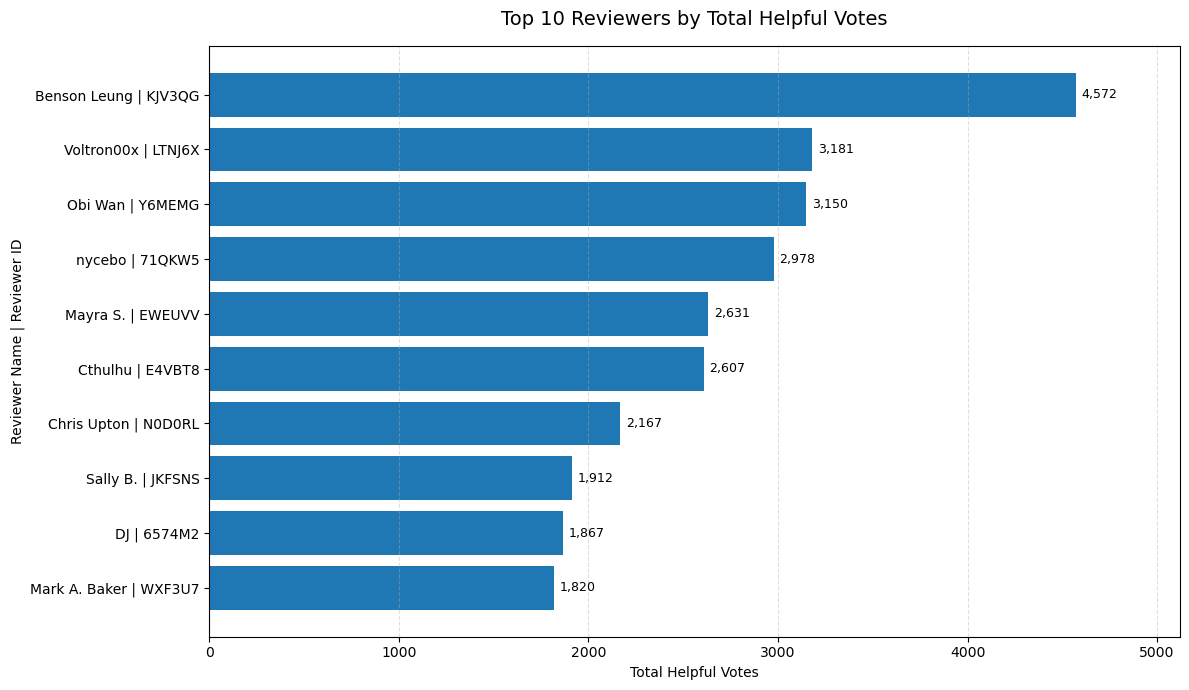


<div dir="rtl" align="right">

### نتیجه تحلیلی سؤال ۳

کاربر **Benson Leung** با شناسه
`A25GROL6KJV3QG` و مجموع
**4,572 رأی مفید**
در رتبه اول قرار دارد.

این کاربر در مجموع **29 نظر**
ثبت کرده که **29 مورد**
از آن‌ها حداقل یک مقدار رأی ثبت‌شده داشته‌اند.

سهم کاربر اول از مجموع رأی مفید ۱۰ کاربر برتر حدود
**17.01 درصد** است.

نتایج نشان می‌دهند که میزان مفید بودن نظرات تنها به تعداد نظرات
وابسته نیست؛ ممکن است یک کاربر با تعداد نظر کمتر، چند نظر بسیار
پربازخورد داشته باشد و مجموع رأی مفید بیشتری کسب کند.

</div>


In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display


# تبدیل نهایی vote به عدد صحیح و جایگزینی مقادیر خالی با صفر
labeled_reviews["vote_clean"] = (
    labeled_reviews["vote_numeric"]
    .fillna(0)
    .astype("Int64")
)

# پاک‌سازی نام کاربران
reviewer_names = (
    labeled_reviews[
        ["reviewerID", "reviewerName"]
    ]
    .copy()
)

reviewer_names["reviewerName"] = (
    reviewer_names["reviewerName"]
    .astype("string")
    .str.strip()
    .replace("", pd.NA)
)

# شمارش فراوانی هر نام برای هر reviewerID
reviewer_name_counts = (
    reviewer_names
    .dropna(subset=["reviewerName"])
    .groupby(
        ["reviewerID", "reviewerName"],
        as_index=False,
        observed=True,
    )
    .size()
    .rename(columns={"size": "name_frequency"})
)

# انتخاب پرتکرارترین نام برای هر شناسه
preferred_reviewer_names = (
    reviewer_name_counts
    .sort_values(
        by=[
            "reviewerID",
            "name_frequency",
            "reviewerName",
        ],
        ascending=[True, False, True],
        kind="stable",
    )
    .drop_duplicates(
        subset="reviewerID",
        keep="first",
    )
    [["reviewerID", "reviewerName"]]
)

# تجمیع آمار هر کاربر
reviewer_statistics = (
    labeled_reviews
    .groupby(
        "reviewerID",
        as_index=False,
        observed=True,
    )
    .agg(
        total_vote=("vote_clean", "sum"),
        review_count=("row_id", "size"),
        reviews_with_vote=(
            "vote_numeric",
            "count",
        ),
    )
)

# اضافه‌کردن نام مناسب برای نمایش
reviewer_statistics = reviewer_statistics.merge(
    preferred_reviewer_names,
    on="reviewerID",
    how="left",
    validate="one_to_one",
)

reviewer_statistics["reviewerName"] = (
    reviewer_statistics["reviewerName"]
    .fillna("نام ثبت نشده")
)

# انتخاب ۱۰ کاربر برتر
top_10_helpful_reviewers = (
    reviewer_statistics
    .sort_values(
        by=[
            "total_vote",
            "review_count",
            "reviewerID",
        ],
        ascending=[False, False, True],
        kind="stable",
    )
    .head(10)
    .copy()
)

top_10_helpful_reviewers.insert(
    0,
    "rank",
    range(1, len(top_10_helpful_reviewers) + 1),
)

# ترتیب ستون‌های جدول نهایی
top_10_helpful_reviewers = top_10_helpful_reviewers[
    [
        "rank",
        "reviewerID",
        "reviewerName",
        "total_vote",
        "review_count",
        "reviews_with_vote",
    ]
]

top_10_helpful_reviewers_display = (
    top_10_helpful_reviewers
    .rename(
        columns={
            "rank": "رتبه",
            "reviewerID": "شناسه کاربر",
            "reviewerName": "نام کاربر",
            "total_vote": "مجموع رأی مفید",
            "review_count": "تعداد نظرات",
            "reviews_with_vote": "نظرات دارای رأی",
        }
    )
)

print("۱۰ کاربر دارای بیشترین مجموع رأی مفید:")
display(top_10_helpful_reviewers_display.style.hide(axis="index"))

# ساخت برچسب خوانا برای نمودار
plot_data = (
    top_10_helpful_reviewers
    .sort_values("total_vote", ascending=True)
    .copy()
)

plot_data["plot_label"] = (
    plot_data["reviewerName"]
    .str.slice(0, 28)
    + " | "
    + plot_data["reviewerID"].str.slice(-6)
)

# رسم نمودار میله‌ای افقی
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    plot_data["plot_label"],
    plot_data["total_vote"],
)

ax.set_title(
    "Top 10 Reviewers by Total Helpful Votes",
    fontsize=14,
    pad=15,
)
ax.set_xlabel("Total Helpful Votes")
ax.set_ylabel("Reviewer Name | Reviewer ID")
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4,
)

ax.bar_label(
    bars,
    labels=[
        f"{value:,.0f}"
        for value in plot_data["total_vote"]
    ],
    padding=4,
    fontsize=9,
)

ax.margins(x=0.12)
plt.tight_layout()
plt.show()


# تولید توضیح تحلیلی فارسی بر اساس نتیجه واقعی
top_reviewer = top_10_helpful_reviewers.iloc[0]

top_10_vote_sum = (
    top_10_helpful_reviewers["total_vote"].sum()
)

top_reviewer_share = (
    top_reviewer["total_vote"]
    / top_10_vote_sum
    * 100
)

analysis_text = f"""
<div dir="rtl" align="right">

### نتیجه تحلیلی سؤال ۳

کاربر **{top_reviewer["reviewerName"]}** با شناسه
`{top_reviewer["reviewerID"]}` و مجموع
**{top_reviewer["total_vote"]:,} رأی مفید**
در رتبه اول قرار دارد.

این کاربر در مجموع **{top_reviewer["review_count"]:,} نظر**
ثبت کرده که **{top_reviewer["reviews_with_vote"]:,} مورد**
از آن‌ها حداقل یک مقدار رأی ثبت‌شده داشته‌اند.

سهم کاربر اول از مجموع رأی مفید ۱۰ کاربر برتر حدود
**{top_reviewer_share:.2f} درصد** است.

نتایج نشان می‌دهند که میزان مفید بودن نظرات تنها به تعداد نظرات
وابسته نیست؛ ممکن است یک کاربر با تعداد نظر کمتر، چند نظر بسیار
پربازخورد داشته باشد و مجموع رأی مفید بیشتری کسب کند.

</div>
"""

display(Markdown(analysis_text))

<div dir="rtl" align="right">

## بررسی سازگاری اطلاعات محصولات

پیش از تحلیل محصولاتی که بیشترین امتیاز ۵ را دریافت کرده‌اند، سازگاری ستون‌های `brand` و `title` برای هر شناسه محصول بررسی می‌شود.

از آنجا که اطلاعات محصول از قبل به داده‌های پاک‌سازی‌شده اضافه شده است، نیازی به Merge مجدد با فایل نگاشت وجود ندارد. بااین‌حال باید اطمینان حاصل شود که هر `asin` به یک برند و عنوان مشخص نگاشت شده و اختلاف‌های احتمالی باعث انتخاب اطلاعات نادرست در جدول نهایی نمی‌شوند.

</div>

In [7]:
from pathlib import Path

import pandas as pd
from IPython.display import display


# ایجاد نسخه مستقل از ستون‌های اطلاعات محصول
product_metadata = labeled_reviews[
    ["asin", "brand", "title"]
].copy()

# پاک‌سازی فاصله‌های ابتدا و انتهای رشته‌ها
for column in ["asin", "brand", "title"]:
    product_metadata[column] = (
        product_metadata[column]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )

# تعداد محصولات یکتا
unique_product_count = product_metadata["asin"].nunique(dropna=True)

# تعداد brand و title یکتا برای هر asin
product_consistency = (
    product_metadata
    .groupby(
        "asin",
        observed=True,
    )
    .agg(
        unique_brand_count=("brand", "nunique"),
        unique_title_count=("title", "nunique"),
        missing_brand_count=("brand", lambda values: values.isna().sum()),
        missing_title_count=("title", lambda values: values.isna().sum()),
        review_count=("asin", "size"),
    )
    .reset_index()
)

# محصولات دارای بیش از یک برند یا عنوان
products_with_multiple_brands = product_consistency[
    product_consistency["unique_brand_count"] > 1
].copy()

products_with_multiple_titles = product_consistency[
    product_consistency["unique_title_count"] > 1
].copy()

# محصولات فاقد اطلاعات کامل
products_without_brand = product_consistency[
    product_consistency["unique_brand_count"] == 0
].copy()

products_without_title = product_consistency[
    product_consistency["unique_title_count"] == 0
].copy()

consistency_summary = pd.DataFrame(
    {
        "بررسی": [
            "تعداد کل محصولات یکتا",
            "محصولات دارای بیش از یک برند",
            "محصولات دارای بیش از یک عنوان",
            "محصولات کاملاً فاقد برند",
            "محصولات کاملاً فاقد عنوان",
        ],
        "تعداد": [
            unique_product_count,
            len(products_with_multiple_brands),
            len(products_with_multiple_titles),
            len(products_without_brand),
            len(products_without_title),
        ],
    }
)

print("خلاصه سازگاری اطلاعات محصولات:")
display(consistency_summary.style.hide(axis="index"))

print("نمونه محصولات دارای چند برند:")
if products_with_multiple_brands.empty:
    print("هیچ محصولی با بیش از یک برند پیدا نشد.")
else:
    display(
        products_with_multiple_brands
        .sort_values(
            "unique_brand_count",
            ascending=False,
        )
        .head(20)
        .style.hide(axis="index")
    )

print("نمونه محصولات دارای چند عنوان:")
if products_with_multiple_titles.empty:
    print("هیچ محصولی با بیش از یک عنوان پیدا نشد.")
else:
    display(
        products_with_multiple_titles
        .sort_values(
            "unique_title_count",
            ascending=False,
        )
        .head(20)
        .style.hide(axis="index")
    )


def dataframe_to_markdown(dataframe: pd.DataFrame) -> str:
    try:
        return dataframe.to_markdown(index=False)
    except ImportError:
        return (
            "```text\n"
            + dataframe.to_string(index=False)
            + "\n```"
        )


# ذخیره گزارش بدون بازنویسی فایل قبلی
REPORT_DIR = Path(
    "/home/ali/GoogleDrive/AI_Project2/outputs/nlp"
)

base_report_path = REPORT_DIR / "nlp_product_metadata_validation.md"
report_path = base_report_path
report_number = 2

while report_path.exists():
    report_path = (
        REPORT_DIR
        / f"nlp_product_metadata_validation_{report_number}.md"
    )
    report_number += 1

report_sections = [
    "# گزارش بررسی سازگاری اطلاعات محصولات",
    "",
    "## خلاصه بررسی",
    "",
    dataframe_to_markdown(consistency_summary),
    "",
    "## نمونه محصولات دارای بیش از یک برند",
    "",
    (
        "هیچ موردی یافت نشد."
        if products_with_multiple_brands.empty
        else dataframe_to_markdown(
            products_with_multiple_brands
            .sort_values(
                "unique_brand_count",
                ascending=False,
            )
            .head(20)
        )
    ),
    "",
    "## نمونه محصولات دارای بیش از یک عنوان",
    "",
    (
        "هیچ موردی یافت نشد."
        if products_with_multiple_titles.empty
        else dataframe_to_markdown(
            products_with_multiple_titles
            .sort_values(
                "unique_title_count",
                ascending=False,
            )
            .head(20)
        )
    ),
]

REPORT_DIR.mkdir(parents=True, exist_ok=True)

report_path.write_text(
    "\n".join(report_sections),
    encoding="utf-8",
)

print("\nگزارش ذخیره شد:")
print(report_path)

خلاصه سازگاری اطلاعات محصولات:


بررسی,تعداد
تعداد کل محصولات یکتا,90715
محصولات دارای بیش از یک برند,0
محصولات دارای بیش از یک عنوان,0
محصولات کاملاً فاقد برند,255
محصولات کاملاً فاقد عنوان,28


نمونه محصولات دارای چند برند:
هیچ محصولی با بیش از یک برند پیدا نشد.
نمونه محصولات دارای چند عنوان:
هیچ محصولی با بیش از یک عنوان پیدا نشد.

گزارش ذخیره شد:
/home/ali/GoogleDrive/AI_Project2/outputs/nlp/nlp_product_metadata_validation.md


<div dir="rtl" align="right">

## سؤال ۵: محصولاتی که بیشترین امتیاز ۵ را دریافت کرده‌اند

برای پاسخ به این سؤال، ابتدا نظراتی که مقدار `overall` آن‌ها برابر ۵ است انتخاب می‌شوند. سپس تعداد این نظرات برای هر شناسه محصول `asin` محاسبه خواهد شد.

اطلاعات برند و عنوان محصول از ستون‌های موجود در داده پاک‌سازی‌شده استخراج می‌شوند. بررسی مرحله قبل نشان داد که هر `asin` حداکثر یک برند و یک عنوان یکتا دارد؛ بنابراین اتصال اطلاعات محصولات به شمارش امتیازهای ۵ با رابطه یک‌به‌یک انجام می‌شود.

محصولات فاقد برند یا عنوان حذف نمی‌شوند و با برچسب مناسب نمایش داده خواهند شد.

</div>

کنترل سلامت اتصال اطلاعات محصولات:


بررسی,تعداد
تعداد محصولات پیش از Merge,71489
تعداد محصولات پس از Merge,71489
محصولات دارای امتیاز ۵ و فاقد برند,199
محصولات دارای امتیاز ۵ و فاقد عنوان,21


۱۰ محصول دارای بیشترین تعداد امتیاز ۵:


رتبه,شناسه محصول,برند,عنوان محصول,تعداد نظرات با امتیاز ۵
1,B010OYASRG,Cambridge Soundworks,"OontZ Angle 3 Enhanced Stereo Edition IPX5 Splashproof Portable Bluetooth Speaker with Volume Booster AMP 10 Watts Power, Custom Bass Radiator, 100' Wireless Range Bluetooth 4.2",1163
2,B00L0YLRUW,NETGEAR,NETGEAR N300 WiFi Range Extender (EX2700),658
3,B01DA0YCNC,Roku,Roku Streaming Stick (3600R) - HD Streaming Player with Quad-Core Processor,600
4,B0043T7FXE,Logitech,"Logitech M570 Wireless Trackball Mouse – Ergonomic Design with Sculpted Right-hand Shape, Compatible with Apple Mac and Microsoft Windows Computers, USB Unifying Receiver, Dark Gray",552
5,B00OBRE5UE,Samsung,Samsung 850 EVO 500GB 2.5-Inch SATA III Internal SSD (MZ-75E500B/AM),529
6,B00S9SGNNS,Asus,"ASUS Tri-Band Gigabit (AC3200) WiFi Router (Up to 3167 Mbps) with MU-MIMO to ensure Lag-Free Gaming, AiProtection network security powered by Trend Micro, Adaptive QoS and Parental Control (RT-AC3200)",442
7,B00P7EVST6,"Arlo Technologies, Inc",Arlo - Wireless Home Security Camera System | Indoor/Outdoor | 2 camera kit (Discontinued),433
8,B00OAJ412U,Samsung,Samsung 850 EVO 250GB 2.5-Inch SATA III Internal SSD (MZ-75E250B/AM),431
9,B00DIF2BO2,Cheetah,"Cheetah Mounts APFMSB TV Wall Mount Bracket for 20-55” TVs Up To VESA 400 and 115 lbs including a Twisted Veins 10’ HDMI Cable and a 6"" 3-Axis Magnetic Bubble Level",428
10,B00JX1ZS5O,Sabrent,Sabrent 4-Port USB 3.0 Hub with Individual LED Power Switches (HB-UM43),415


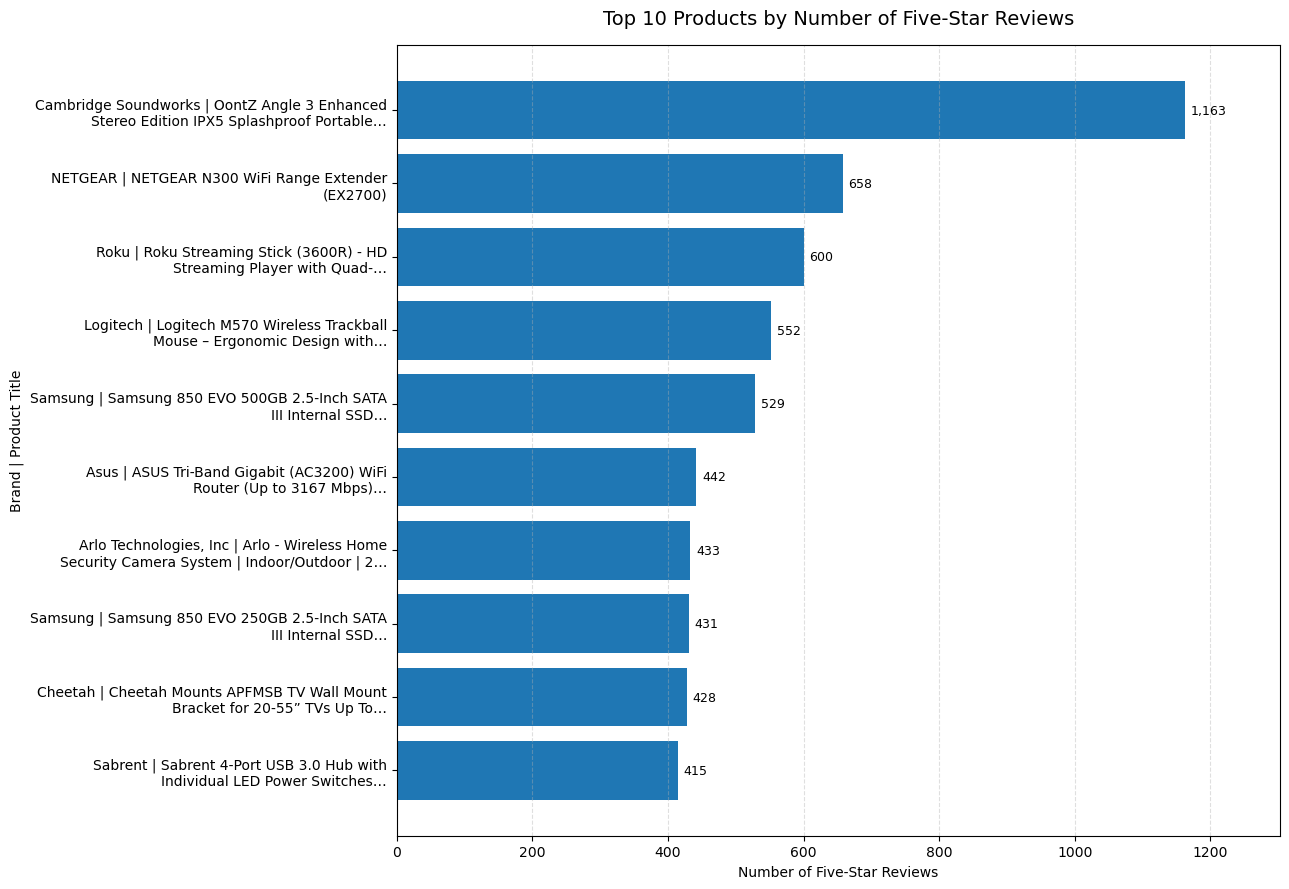


<div dir="rtl" align="right">

### نتیجه تحلیلی سؤال ۵

محصول **OontZ Angle 3 Enhanced Stereo Edition IPX5 Splashproof Portable Bluetooth Speaker with Volume Booster AMP 10 Watts Power, Custom Bass Radiator, 100' Wireless Range Bluetooth 4.2** از برند
**Cambridge Soundworks** با شناسه
`B010OYASRG` و تعداد
**1,163 نظر با امتیاز ۵**
در رتبه اول قرار دارد.

سهم این محصول از کل **456,476 نظر دارای امتیاز ۵**
حدود **0.25 درصد** است.

در مجموع، ۱۰ محصول برتر
**5,651 نظر با امتیاز ۵** دریافت کرده‌اند که
حدود **1.24 درصد** از تمام نظرات دارای امتیاز ۵ را
تشکیل می‌دهد.

در میان ۱۰ محصول برتر، تعداد
**0 محصول فاقد برند**
و **0 محصول فاقد عنوان** وجود دارد.

</div>


In [8]:
import html
from textwrap import fill, shorten

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display


# ایجاد نسخه مستقل از ستون‌های موردنیاز
product_reviews = labeled_reviews[
    ["asin", "overall", "brand", "title"]
].copy()

# پاک‌سازی ستون‌های متنی
for column in ["asin", "brand", "title"]:
    product_reviews[column] = (
        product_reviews[column]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )

# ساخت جدول یکتای شناسه محصولات
all_products = (
    product_reviews[["asin"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

# استخراج تنها مقدار غیرخالی برند برای هر محصول
brand_lookup = (
    product_reviews
    .dropna(subset=["brand"])
    [["asin", "brand"]]
    .drop_duplicates()
)

# استخراج تنها مقدار غیرخالی عنوان برای هر محصول
title_lookup = (
    product_reviews
    .dropna(subset=["title"])
    [["asin", "title"]]
    .drop_duplicates()
)

# ساخت جدول اطلاعات محصولات با کنترل رابطه یک‌به‌یک
product_lookup = (
    all_products
    .merge(
        brand_lookup,
        on="asin",
        how="left",
        validate="one_to_one",
    )
    .merge(
        title_lookup,
        on="asin",
        how="left",
        validate="one_to_one",
    )
)

# انتخاب تمام نظرات دارای امتیاز ۵
five_star_reviews = product_reviews.loc[
    product_reviews["overall"].eq(5),
    ["asin"],
].copy()

# شمارش تعداد امتیازهای ۵ برای هر محصول
five_star_counts = (
    five_star_reviews
    .groupby(
        "asin",
        as_index=False,
        observed=True,
    )
    .size()
    .rename(
        columns={
            "size": "five_star_review_count",
        }
    )
)

rows_before_merge = len(five_star_counts)

# اتصال شمارش امتیازهای ۵ به اطلاعات محصولات
five_star_products = five_star_counts.merge(
    product_lookup,
    on="asin",
    how="left",
    validate="one_to_one",
)

rows_after_merge = len(five_star_products)

# کنترل عدم تغییر تعداد محصولات پس از Merge
if rows_before_merge != rows_after_merge:
    raise RuntimeError(
        "تعداد ردیف‌ها پس از اتصال اطلاعات محصولات تغییر کرده است."
    )

# ثبت تعداد اطلاعات گمشده پیش از جایگزینی
missing_brand_count = five_star_products["brand"].isna().sum()
missing_title_count = five_star_products["title"].isna().sum()

# مدیریت مقادیر گمشده بدون حذف محصول
five_star_products["brand"] = (
    five_star_products["brand"]
    .fillna("برند نامشخص")
)

five_star_products["title"] = (
    five_star_products["title"]
    .fillna("عنوان نامشخص")
)

# تبدیل موجودیت‌های HTML مانند &amp; برای نمایش خواناتر
for column in ["brand", "title"]:
    five_star_products[column] = (
        five_star_products[column]
        .map(html.unescape)
        .astype("string")
    )

# مرتب‌سازی و انتخاب ۱۰ محصول برتر
top_10_five_star_products = (
    five_star_products
    .sort_values(
        by=[
            "five_star_review_count",
            "asin",
        ],
        ascending=[False, True],
        kind="stable",
    )
    .head(10)
    .reset_index(drop=True)
    .copy()
)

top_10_five_star_products.insert(
    0,
    "rank",
    range(1, len(top_10_five_star_products) + 1),
)

top_10_five_star_products = top_10_five_star_products[
    [
        "rank",
        "asin",
        "brand",
        "title",
        "five_star_review_count",
    ]
]

# جدول کنترل سلامت Merge
merge_validation = pd.DataFrame(
    {
        "بررسی": [
            "تعداد محصولات پیش از Merge",
            "تعداد محصولات پس از Merge",
            "محصولات دارای امتیاز ۵ و فاقد برند",
            "محصولات دارای امتیاز ۵ و فاقد عنوان",
        ],
        "تعداد": [
            rows_before_merge,
            rows_after_merge,
            missing_brand_count,
            missing_title_count,
        ],
    }
)

print("کنترل سلامت اتصال اطلاعات محصولات:")
display(merge_validation.style.hide(axis="index"))

# جدول نهایی فارسی
top_10_five_star_products_display = (
    top_10_five_star_products
    .rename(
        columns={
            "rank": "رتبه",
            "asin": "شناسه محصول",
            "brand": "برند",
            "title": "عنوان محصول",
            "five_star_review_count": "تعداد نظرات با امتیاز ۵",
        }
    )
)

print("۱۰ محصول دارای بیشترین تعداد امتیاز ۵:")
display(
    top_10_five_star_products_display
    .style
    .hide(axis="index")
)


# آماده‌سازی داده نمودار
plot_data = (
    top_10_five_star_products
    .sort_values(
        "five_star_review_count",
        ascending=True,
    )
    .copy()
)

# ساخت برچسب کوتاه و چندخطی برای عنوان‌های طولانی
plot_data["plot_label"] = plot_data.apply(
    lambda row: fill(
        f'{row["brand"]} | '
        f'{shorten(row["title"], width=65, placeholder="…")}',
        width=48,
    ),
    axis=1,
)

# نمودار میله‌ای افقی
fig, ax = plt.subplots(figsize=(13, 9))

bars = ax.barh(
    plot_data["plot_label"],
    plot_data["five_star_review_count"],
)

ax.set_title(
    "Top 10 Products by Number of Five-Star Reviews",
    fontsize=14,
    pad=15,
)
ax.set_xlabel("Number of Five-Star Reviews")
ax.set_ylabel("Brand | Product Title")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4,
)

ax.bar_label(
    bars,
    labels=[
        f"{value:,.0f}"
        for value in plot_data["five_star_review_count"]
    ],
    padding=4,
    fontsize=9,
)

ax.margins(x=0.12)
plt.tight_layout()
plt.show()


# تولید توضیح تحلیلی بر اساس نتیجه واقعی
top_product = top_10_five_star_products.iloc[0]

total_five_star_reviews = len(five_star_reviews)

top_10_five_star_total = (
    top_10_five_star_products[
        "five_star_review_count"
    ].sum()
)

top_product_share = (
    top_product["five_star_review_count"]
    / total_five_star_reviews
    * 100
)

top_10_share = (
    top_10_five_star_total
    / total_five_star_reviews
    * 100
)

missing_brand_in_top_10 = (
    top_10_five_star_products["brand"]
    .eq("برند نامشخص")
    .sum()
)

missing_title_in_top_10 = (
    top_10_five_star_products["title"]
    .eq("عنوان نامشخص")
    .sum()
)

analysis_text = f"""
<div dir="rtl" align="right">

### نتیجه تحلیلی سؤال ۵

محصول **{top_product["title"]}** از برند
**{top_product["brand"]}** با شناسه
`{top_product["asin"]}` و تعداد
**{top_product["five_star_review_count"]:,} نظر با امتیاز ۵**
در رتبه اول قرار دارد.

سهم این محصول از کل **{total_five_star_reviews:,} نظر دارای امتیاز ۵**
حدود **{top_product_share:.2f} درصد** است.

در مجموع، ۱۰ محصول برتر
**{top_10_five_star_total:,} نظر با امتیاز ۵** دریافت کرده‌اند که
حدود **{top_10_share:.2f} درصد** از تمام نظرات دارای امتیاز ۵ را
تشکیل می‌دهد.

در میان ۱۰ محصول برتر، تعداد
**{missing_brand_in_top_10} محصول فاقد برند**
و **{missing_title_in_top_10} محصول فاقد عنوان** وجود دارد.

</div>
"""

display(Markdown(analysis_text))

<div dir="rtl" align="right">

## بررسی کیفیت و یکدستی نام برندها

پیش از شمارش تعداد نظرات هر برند، مقادیر ستون `brand` از نظر مقادیر گمشده، برچسب‌های نامعتبر، فاصله‌های اضافی و تفاوت در حروف بزرگ و کوچک بررسی می‌شوند.

این کنترل اهمیت دارد؛ زیرا شکل‌های نوشتاری متفاوت یک برند، مانند `ASUS` و `Asus`، ممکن است در گروه‌بندی خام به‌عنوان دو برند مستقل محاسبه شوند. در این مرحله هیچ نامی تغییر نمی‌کند و فقط میزان نیاز به استانداردسازی بررسی می‌شود.

</div>


In [9]:
import re
from pathlib import Path

import pandas as pd
from IPython.display import display


# نسخه مستقل از ستون برند
brand_data = labeled_reviews[
    ["row_id", "brand"]
].copy()

brand_data["brand_raw"] = brand_data["brand"].astype("string")

# پاک‌سازی مقدماتی فقط برای بررسی
brand_data["brand_trimmed"] = (
    brand_data["brand_raw"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .replace("", pd.NA)
)

# نسخه بدون حساسیت به بزرگی و کوچکی حروف
brand_data["brand_casefold"] = (
    brand_data["brand_trimmed"]
    .str.casefold()
)

# برچسب‌هایی که احتمالاً نام واقعی برند نیستند
placeholder_pattern = re.compile(
    r"^(unknown|unk|none|null|nan|n/?a|not available|"
    r"no brand|unbranded|generic|brand unknown|"
    r"does not apply|not applicable|-+)$",
    flags=re.IGNORECASE,
)

placeholder_mask = (
    brand_data["brand_trimmed"]
    .fillna("")
    .str.match(placeholder_pattern)
)

# شمارش شکل‌های نوشتاری هر برند بدون حساسیت به حروف
brand_variants = (
    brand_data
    .dropna(subset=["brand_trimmed"])
    .groupby(
        "brand_casefold",
        observed=True,
    )
    .agg(
        variant_count=("brand_trimmed", "nunique"),
        review_count=("row_id", "size"),
        variants=(
            "brand_trimmed",
            lambda values: sorted(values.dropna().unique().tolist()),
        ),
    )
    .reset_index()
)

case_variant_groups = (
    brand_variants.loc[
        brand_variants["variant_count"] > 1
    ]
    .sort_values(
        ["review_count", "variant_count"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

# پرتکرارترین نام‌های خام برند
top_raw_brands = (
    brand_data["brand_trimmed"]
    .value_counts(dropna=False)
    .head(30)
    .rename_axis("brand")
    .reset_index(name="review_count")
)

# مقادیر مشکوک
placeholder_values = (
    brand_data.loc[
        placeholder_mask,
        "brand_trimmed",
    ]
    .value_counts(dropna=False)
    .rename_axis("مقدار مشکوک")
    .reset_index(name="تعداد نظر")
)

brand_validation_summary = pd.DataFrame(
    {
        "بررسی": [
            "کل نظرات",
            "نظرات فاقد برند",
            "تعداد نام برند یکتا به شکل خام",
            "تعداد برند یکتا پس از حذف فاصله‌های اضافی",
            "تعداد برند یکتا بدون حساسیت به حروف",
            "گروه‌های دارای چند شکل نوشتاری",
            "نظرات دارای برچسب برند مشکوک",
        ],
        "تعداد": [
            len(brand_data),
            brand_data["brand_trimmed"].isna().sum(),
            brand_data["brand_raw"].nunique(dropna=True),
            brand_data["brand_trimmed"].nunique(dropna=True),
            brand_data["brand_casefold"].nunique(dropna=True),
            len(case_variant_groups),
            placeholder_mask.sum(),
        ],
    }
)

print("خلاصه اعتبارسنجی نام برندها:")
display(
    brand_validation_summary
    .style
    .hide(axis="index")
)

print("پرتکرارترین نام‌های برند به شکل فعلی:")
display(
    top_raw_brands
    .style
    .hide(axis="index")
)

print("مقادیر مشکوک یا نامعتبر:")
if placeholder_values.empty:
    print("هیچ برچسب مشکوکی پیدا نشد.")
else:
    display(
        placeholder_values
        .style
        .hide(axis="index")
    )

print("نمونه برندهای دارای چند شکل نوشتاری:")
if case_variant_groups.empty:
    print("هیچ اختلافی ناشی از بزرگی و کوچکی حروف پیدا نشد.")
else:
    display(
        case_variant_groups[
            [
                "variant_count",
                "review_count",
                "variants",
            ]
        ]
        .head(30)
        .style
        .hide(axis="index")
    )


def dataframe_to_markdown(dataframe: pd.DataFrame) -> str:
    try:
        return dataframe.to_markdown(index=False)
    except ImportError:
        return (
            "```text\n"
            + dataframe.to_string(index=False)
            + "\n```"
        )


# ذخیره گزارش بدون بازنویسی فایل قبلی
REPORT_DIR = Path(
    "/home/ali/GoogleDrive/AI_Project2/outputs/nlp"
)

base_report_path = REPORT_DIR / "nlp_brand_validation.md"
report_path = base_report_path
report_number = 2

while report_path.exists():
    report_path = (
        REPORT_DIR
        / f"nlp_brand_validation_{report_number}.md"
    )
    report_number += 1

report_sections = [
    "# گزارش اعتبارسنجی نام برندها",
    "",
    "## خلاصه بررسی",
    "",
    dataframe_to_markdown(brand_validation_summary),
    "",
    "## پرتکرارترین نام‌های برند",
    "",
    dataframe_to_markdown(top_raw_brands),
    "",
    "## مقادیر مشکوک",
    "",
    (
        "هیچ مقدار مشکوکی یافت نشد."
        if placeholder_values.empty
        else dataframe_to_markdown(placeholder_values)
    ),
    "",
    "## نمونه برندهای دارای چند شکل نوشتاری",
    "",
    (
        "هیچ موردی یافت نشد."
        if case_variant_groups.empty
        else dataframe_to_markdown(
            case_variant_groups[
                [
                    "variant_count",
                    "review_count",
                    "variants",
                ]
            ].head(30)
        )
    ),
]

report_path.write_text(
    "\n".join(report_sections),
    encoding="utf-8",
)

print("\nگزارش ذخیره شد:")
print(report_path)

خلاصه اعتبارسنجی نام برندها:


بررسی,تعداد
کل نظرات,830612
نظرات فاقد برند,1059
تعداد نام برند یکتا به شکل خام,14590
تعداد برند یکتا پس از حذف فاصله‌های اضافی,14590
تعداد برند یکتا بدون حساسیت به حروف,14246
گروه‌های دارای چند شکل نوشتاری,334
نظرات دارای برچسب برند مشکوک,2015


پرتکرارترین نام‌های برند به شکل فعلی:


brand,review_count
Logitech,16829
Samsung,15400
AmazonBasics,13213
Asus,11882
Sony,11593
Anker,9860
TP-LINK,9773
SanDisk,8347
Sabrent,7307
NETGEAR,6644


مقادیر مشکوک یا نامعتبر:


مقدار مشکوک,تعداد نظر
Generic,1609
Unknown,400
generic,3
no brand,2
Not Available,1


نمونه برندهای دارای چند شکل نوشتاری:


variant_count,review_count,variants
2,15401,"['Samsung', 'samsung']"
2,11598,"['SONY', 'Sony']"
2,3595,"['HP', 'hp']"
2,2555,"['MPOW', 'Mpow']"
2,1634,"['LimoStudio', 'Limostudio']"
2,1612,"['Generic', 'generic']"
3,1541,"['SoundBot', 'Soundbot', 'soundbot']"
2,1535,"['BAOFENG', 'BaoFeng']"
2,1108,"['YONGNUO', 'Yongnuo']"
3,1040,"['AGPTEK', 'AGPtEK', 'AGPtek']"



گزارش ذخیره شد:
/home/ali/GoogleDrive/AI_Project2/outputs/nlp/nlp_brand_validation.md


<div dir="rtl" align="right">

## سؤال ۶: تحلیل برندهای دارای بیشترین تعداد نظر

برای جلوگیری از جداشدن شکل‌های نوشتاری مختلف یک برند، نام برندها پس از حذف فاصله‌های اضافی و بدون حساسیت به بزرگی و کوچکی حروف گروه‌بندی می‌شوند. برای نمایش نتیجه، پرتکرارترین شکل نوشتاری هر برند به‌عنوان نام اصلی انتخاب می‌شود.

مقادیر گمشده و برچسب‌های عمومی یا نامعتبر مانند `Generic`، `Unknown` و `no brand` از تحلیل برندها کنار گذاشته می‌شوند؛ زیرا به یک برند مشخص اشاره نمی‌کنند.

ابتدا ۱۰ برند دارای بیشترین تعداد نظر انتخاب می‌شوند. سپس میانگین امتیاز `overall` فقط برای همین ۱۰ برند محاسبه شده و جدول نهایی بر اساس میانگین امتیاز مرتب می‌شود. بنابراین رتبه نهایی جدول، رتبه بر اساس میانگین امتیاز است، نه تعداد نظر.

</div>

خلاصه آماده‌سازی داده برندها:


بررسی,تعداد
کل نظرات,830612
نظرات فاقد برند,1059
نظرات دارای برچسب برند نامعتبر,2015
نظرات واردشده به تحلیل برند,827538
تعداد برند معتبر استانداردشده,14242


۱۰ برند دارای بیشترین تعداد نظر، مرتب‌شده بر اساس میانگین امتیاز:


رتبه بر اساس میانگین امتیاز,برند,تعداد نظرات,میانگین امتیاز,رتبه بر اساس تعداد نظر
1,Anker,"9,860",4.244,6
2,AmazonBasics,"13,213",4.201,3
3,Sabrent,"7,307",4.028,9
4,SanDisk,"8,347",3.957,8
5,Logitech,"16,829",3.951,1
6,Samsung,"15,401",3.941,2
7,TP-LINK,"9,773",3.929,7
8,Sony,"11,598",3.918,5
9,Asus,"11,882",3.855,4
10,NETGEAR,"6,644",3.810,10


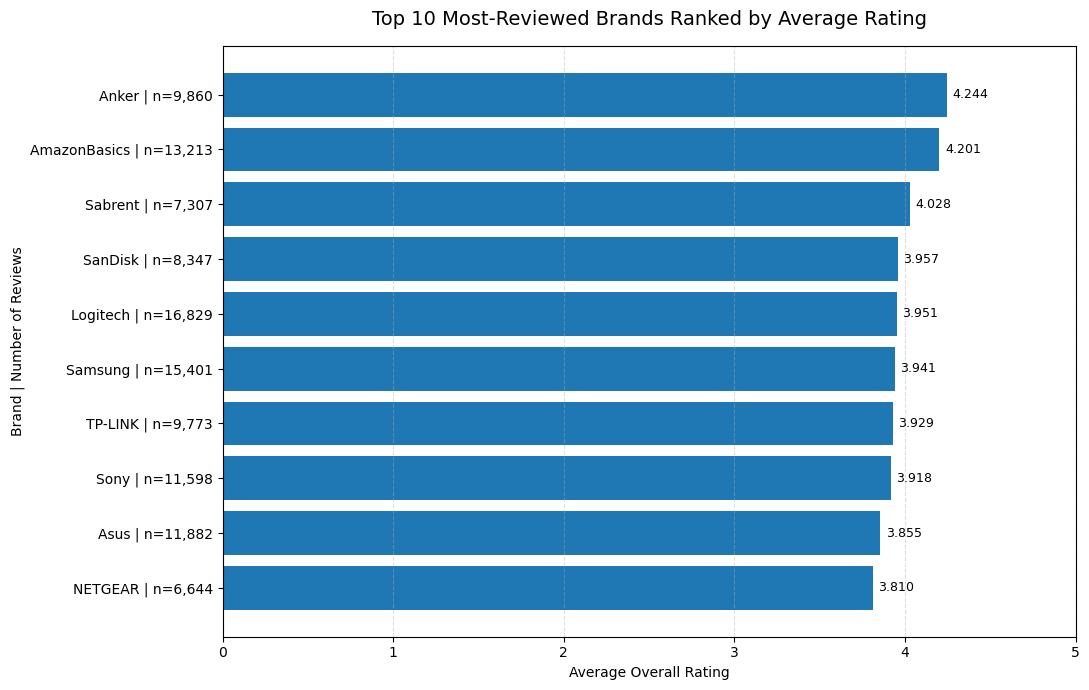


<div dir="rtl" align="right">

### نتیجه تحلیلی سؤال ۶

این ۱۰ برند ابتدا بر اساس **تعداد کل نظرات** انتخاب شده‌اند،
اما رتبه نهایی جدول بر اساس **میانگین امتیاز** است.

در میان این برندها، **Anker**
با میانگین امتیاز **4.244**
و تعداد **9,860 نظر**
بالاترین میانگین امتیاز را دارد.

برند **Logitech** با **16,829 نظر** پرتعدادترین برند است، اما با میانگین امتیاز **3.951** در رتبه **5** میانگین امتیاز قرار گرفته است.

این مقایسه نشان می‌دهد که تعداد زیاد نظرات لزوماً به معنی
میانگین امتیاز بالاتر نیست؛ تعداد نظر میزان فراگیری و حجم بازخورد
را نشان می‌دهد، درحالی‌که میانگین امتیاز بیانگر سطح رضایت کاربران است.

</div>


In [10]:
import re

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display


# ایجاد نسخه مستقل از ستون‌های موردنیاز
brand_reviews = labeled_reviews[
    ["brand", "overall"]
].copy()

# پاک‌سازی مقدماتی نام برند
brand_reviews["brand_display"] = (
    brand_reviews["brand"]
    .astype("string")
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .replace("", pd.NA)
)

# کلید استاندارد برای یکسان‌سازی تفاوت حروف بزرگ و کوچک
brand_reviews["brand_key"] = (
    brand_reviews["brand_display"]
    .str.casefold()
)

# مقادیری که یک برند مشخص را معرفی نمی‌کنند
invalid_brand_pattern = re.compile(
    r"^(unknown|unk|none|null|nan|n/?a|not available|"
    r"no brand|unbranded|generic|brand unknown|"
    r"does not apply|not applicable|-+)$",
    flags=re.IGNORECASE,
)

invalid_brand_mask = (
    brand_reviews["brand_display"]
    .fillna("")
    .str.match(invalid_brand_pattern)
)

missing_brand_mask = brand_reviews["brand_display"].isna()

# فقط برندهای معتبر وارد تحلیل می‌شوند
valid_brand_reviews = brand_reviews.loc[
    ~missing_brand_mask & ~invalid_brand_mask
].copy()

# شمارش فراوانی هر شکل نوشتاری برای انتخاب نام نمایشی مناسب
brand_name_frequencies = (
    valid_brand_reviews
    .groupby(
        ["brand_key", "brand_display"],
        as_index=False,
        observed=True,
    )
    .size()
    .rename(columns={"size": "name_frequency"})
)

# انتخاب پرتکرارترین شکل نوشتاری هر برند
canonical_brand_names = (
    brand_name_frequencies
    .sort_values(
        by=[
            "brand_key",
            "name_frequency",
            "brand_display",
        ],
        ascending=[True, False, True],
        kind="stable",
    )
    .drop_duplicates(
        subset="brand_key",
        keep="first",
    )
    [["brand_key", "brand_display"]]
    .rename(columns={"brand_display": "brand"})
)

# محاسبه تعداد نظر و میانگین امتیاز تمام برندهای معتبر
brand_statistics = (
    valid_brand_reviews
    .groupby(
        "brand_key",
        as_index=False,
        observed=True,
    )
    .agg(
        review_count=("overall", "size"),
        average_rating=("overall", "mean"),
    )
    .merge(
        canonical_brand_names,
        on="brand_key",
        how="left",
        validate="one_to_one",
    )
)

# رتبه تمام برندها بر اساس تعداد نظر
brand_statistics = (
    brand_statistics
    .sort_values(
        by=[
            "review_count",
            "brand",
        ],
        ascending=[False, True],
        kind="stable",
    )
    .reset_index(drop=True)
)

brand_statistics["review_count_rank"] = (
    range(1, len(brand_statistics) + 1)
)

# انتخاب ۱۰ برند دارای بیشترین تعداد نظر
top_10_most_reviewed_brands = (
    brand_statistics
    .head(10)
    .copy()
)

# مرتب‌سازی نهایی فقط همین ۱۰ برند بر اساس میانگین امتیاز
top_10_reviewed_brands_ratings = (
    top_10_most_reviewed_brands
    .sort_values(
        by=[
            "average_rating",
            "review_count",
            "brand",
        ],
        ascending=[False, False, True],
        kind="stable",
    )
    .reset_index(drop=True)
)

top_10_reviewed_brands_ratings.insert(
    0,
    "average_rating_rank",
    range(1, len(top_10_reviewed_brands_ratings) + 1),
)

# گردکردن فقط برای نمایش؛ مقدار اصلی برای محاسبات حفظ می‌شود
top_10_reviewed_brands_ratings["average_rating_display"] = (
    top_10_reviewed_brands_ratings["average_rating"]
    .round(3)
)

# خلاصه مدیریت داده‌های نامعتبر
brand_cleaning_summary = pd.DataFrame(
    {
        "بررسی": [
            "کل نظرات",
            "نظرات فاقد برند",
            "نظرات دارای برچسب برند نامعتبر",
            "نظرات واردشده به تحلیل برند",
            "تعداد برند معتبر استانداردشده",
        ],
        "تعداد": [
            len(brand_reviews),
            missing_brand_mask.sum(),
            invalid_brand_mask.sum(),
            len(valid_brand_reviews),
            brand_statistics["brand_key"].nunique(),
        ],
    }
)

print("خلاصه آماده‌سازی داده برندها:")
display(
    brand_cleaning_summary
    .style
    .hide(axis="index")
)

# جدول نهایی فارسی
final_brand_table = (
    top_10_reviewed_brands_ratings[
        [
            "average_rating_rank",
            "brand",
            "review_count",
            "average_rating_display",
            "review_count_rank",
        ]
    ]
    .rename(
        columns={
            "average_rating_rank": "رتبه بر اساس میانگین امتیاز",
            "brand": "برند",
            "review_count": "تعداد نظرات",
            "average_rating_display": "میانگین امتیاز",
            "review_count_rank": "رتبه بر اساس تعداد نظر",
        }
    )
)

print(
    "۱۰ برند دارای بیشترین تعداد نظر، "
    "مرتب‌شده بر اساس میانگین امتیاز:"
)

display(
    final_brand_table
    .style
    .hide(axis="index")
    .format(
        {
            "تعداد نظرات": "{:,}",
            "میانگین امتیاز": "{:.3f}",
        }
    )
)


# آماده‌سازی نمودار
plot_data = (
    top_10_reviewed_brands_ratings
    .sort_values(
        "average_rating",
        ascending=True,
    )
    .copy()
)

plot_data["plot_label"] = (
    plot_data["brand"]
    + " | n="
    + plot_data["review_count"].map(lambda value: f"{value:,}")
)

# نمودار مقایسه میانگین امتیاز
fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    plot_data["plot_label"],
    plot_data["average_rating"],
)

ax.set_title(
    "Top 10 Most-Reviewed Brands Ranked by Average Rating",
    fontsize=14,
    pad=15,
)
ax.set_xlabel("Average Overall Rating")
ax.set_ylabel("Brand | Number of Reviews")
ax.set_xlim(0, 5)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4,
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.3f}"
        for value in plot_data["average_rating"]
    ],
    padding=4,
    fontsize=9,
)

ax.margins(x=0.08)
plt.tight_layout()
plt.show()


# تولید توضیح تحلیلی بر اساس خروجی واقعی
highest_rated_brand = (
    top_10_reviewed_brands_ratings.iloc[0]
)

most_reviewed_brand = (
    top_10_most_reviewed_brands
    .sort_values(
        "review_count",
        ascending=False,
    )
    .iloc[0]
)

most_reviewed_rating_rank = int(
    top_10_reviewed_brands_ratings.loc[
        top_10_reviewed_brands_ratings["brand_key"].eq(
            most_reviewed_brand["brand_key"]
        ),
        "average_rating_rank",
    ].iloc[0]
)

if (
    highest_rated_brand["brand_key"]
    == most_reviewed_brand["brand_key"]
):
    comparison_text = (
        "در این داده، همین برند هم بیشترین تعداد نظر و هم "
        "بالاترین میانگین امتیاز را در میان ۱۰ برند منتخب دارد."
    )
else:
    comparison_text = (
        f'برند **{most_reviewed_brand["brand"]}** با '
        f'**{most_reviewed_brand["review_count"]:,} نظر** '
        f'پرتعدادترین برند است، اما با میانگین امتیاز '
        f'**{most_reviewed_brand["average_rating"]:.3f}** '
        f'در رتبه **{most_reviewed_rating_rank}** '
        f'میانگین امتیاز قرار گرفته است.'
    )

analysis_text = f"""
<div dir="rtl" align="right">

### نتیجه تحلیلی سؤال ۶

این ۱۰ برند ابتدا بر اساس **تعداد کل نظرات** انتخاب شده‌اند،
اما رتبه نهایی جدول بر اساس **میانگین امتیاز** است.

در میان این برندها، **{highest_rated_brand["brand"]}**
با میانگین امتیاز **{highest_rated_brand["average_rating"]:.3f}**
و تعداد **{highest_rated_brand["review_count"]:,} نظر**
بالاترین میانگین امتیاز را دارد.

{comparison_text}

این مقایسه نشان می‌دهد که تعداد زیاد نظرات لزوماً به معنی
میانگین امتیاز بالاتر نیست؛ تعداد نظر میزان فراگیری و حجم بازخورد
را نشان می‌دهد، درحالی‌که میانگین امتیاز بیانگر سطح رضایت کاربران است.

</div>
"""

display(Markdown(analysis_text))

<div dir="rtl" align="right">

## کنترل نهایی خروجی سؤال‌های ۳، ۵ و ۶

پیش از ذخیره جدول‌های نهایی، ساختار و ترتیب هر سه خروجی بررسی می‌شود.

در این کنترل، تعداد ردیف‌ها، یکتایی شناسه‌ها، نبود مقادیر گمشده، ترتیب نزولی معیارهای رتبه‌بندی و محدوده معتبر مقادیر بررسی می‌شوند. همچنین اطمینان حاصل می‌شود که برندهای سؤال ۶ دقیقاً همان ۱۰ برند دارای بیشترین تعداد نظر هستند.

این مرحله هیچ فایل CSV نهایی ایجاد یا بازنویسی نمی‌کند.

</div>

In [11]:
from pathlib import Path

import pandas as pd
from IPython.display import display


audit_results = []


def add_audit(check_name: str, condition: bool, details: str) -> None:
    """افزودن نتیجه یک کنترل به جدول ممیزی."""
    audit_results.append(
        {
            "کنترل": check_name,
            "وضعیت": "موفق" if condition else "ناموفق",
            "توضیحات": details,
        }
    )


# -----------------------------
# کنترل خروجی سؤال ۳
# -----------------------------
add_audit(
    "تعداد ردیف‌های سؤال ۳",
    len(top_10_helpful_reviewers) == 10,
    f"{len(top_10_helpful_reviewers)} ردیف",
)

add_audit(
    "یکتایی reviewerID در سؤال ۳",
    top_10_helpful_reviewers["reviewerID"].is_unique,
    "هر کاربر باید فقط یک‌بار نمایش داده شود.",
)

add_audit(
    "ترتیب مجموع رأی مفید در سؤال ۳",
    top_10_helpful_reviewers["total_vote"].is_monotonic_decreasing,
    "مقادیر باید نزولی باشند.",
)

add_audit(
    "رتبه‌های سؤال ۳",
    top_10_helpful_reviewers["rank"].tolist() == list(range(1, 11)),
    "رتبه‌ها باید از ۱ تا ۱۰ باشند.",
)

add_audit(
    "مقادیر گمشده سؤال ۳",
    not top_10_helpful_reviewers[
        ["reviewerID", "reviewerName", "total_vote"]
    ].isna().any().any(),
    "ستون‌های اصلی نباید مقدار گمشده داشته باشند.",
)

add_audit(
    "مقادیر منفی رأی مفید",
    top_10_helpful_reviewers["total_vote"].ge(0).all(),
    "مجموع رأی مفید باید نامنفی باشد.",
)


# -----------------------------
# کنترل خروجی سؤال ۵
# -----------------------------
add_audit(
    "تعداد ردیف‌های سؤال ۵",
    len(top_10_five_star_products) == 10,
    f"{len(top_10_five_star_products)} ردیف",
)

add_audit(
    "یکتایی asin در سؤال ۵",
    top_10_five_star_products["asin"].is_unique,
    "هر محصول باید فقط یک‌بار نمایش داده شود.",
)

add_audit(
    "ترتیب تعداد امتیاز ۵ در سؤال ۵",
    top_10_five_star_products[
        "five_star_review_count"
    ].is_monotonic_decreasing,
    "تعداد امتیازهای ۵ باید نزولی باشد.",
)

add_audit(
    "رتبه‌های سؤال ۵",
    top_10_five_star_products["rank"].tolist() == list(range(1, 11)),
    "رتبه‌ها باید از ۱ تا ۱۰ باشند.",
)

add_audit(
    "مقادیر گمشده سؤال ۵",
    not top_10_five_star_products[
        ["asin", "brand", "title", "five_star_review_count"]
    ].isna().any().any(),
    "ستون‌های اصلی نباید مقدار گمشده داشته باشند.",
)

add_audit(
    "مثبت‌بودن تعداد امتیازهای ۵",
    top_10_five_star_products[
        "five_star_review_count"
    ].gt(0).all(),
    "تعداد امتیازهای ۵ باید مثبت باشد.",
)


# -----------------------------
# کنترل خروجی سؤال ۶
# -----------------------------
add_audit(
    "تعداد ردیف‌های سؤال ۶",
    len(top_10_reviewed_brands_ratings) == 10,
    f"{len(top_10_reviewed_brands_ratings)} ردیف",
)

add_audit(
    "یکتایی برندها در سؤال ۶",
    top_10_reviewed_brands_ratings["brand_key"].is_unique,
    "هر برند استانداردشده باید فقط یک‌بار نمایش داده شود.",
)

add_audit(
    "ترتیب میانگین امتیاز در سؤال ۶",
    top_10_reviewed_brands_ratings[
        "average_rating"
    ].is_monotonic_decreasing,
    "جدول نهایی باید بر اساس میانگین امتیاز نزولی باشد.",
)

add_audit(
    "رتبه‌های میانگین امتیاز سؤال ۶",
    top_10_reviewed_brands_ratings[
        "average_rating_rank"
    ].tolist() == list(range(1, 11)),
    "رتبه‌ها باید از ۱ تا ۱۰ باشند.",
)

add_audit(
    "محدوده میانگین امتیاز سؤال ۶",
    top_10_reviewed_brands_ratings[
        "average_rating"
    ].between(1, 5).all(),
    "تمام میانگین‌ها باید بین ۱ و ۵ باشند.",
)

add_audit(
    "مقادیر گمشده سؤال ۶",
    not top_10_reviewed_brands_ratings[
        ["brand", "review_count", "average_rating"]
    ].isna().any().any(),
    "ستون‌های اصلی نباید مقدار گمشده داشته باشند.",
)

expected_top_brand_keys = set(
    brand_statistics
    .head(10)["brand_key"]
)

actual_top_brand_keys = set(
    top_10_reviewed_brands_ratings["brand_key"]
)

add_audit(
    "انطباق با ۱۰ برند دارای بیشترین تعداد نظر",
    actual_top_brand_keys == expected_top_brand_keys,
    "برندهای جدول باید دقیقاً همان ۱۰ برند پرتعداد باشند.",
)


# -----------------------------
# نمایش نتیجه ممیزی
# -----------------------------
audit_table = pd.DataFrame(audit_results)

print("نتیجه کنترل نهایی:")
display(
    audit_table
    .style
    .hide(axis="index")
)

failed_checks = audit_table.loc[
    audit_table["وضعیت"].eq("ناموفق")
]

if failed_checks.empty:
    print("تمام کنترل‌ها با موفقیت انجام شدند.")
else:
    print(
        f"{len(failed_checks)} کنترل ناموفق است و باید بررسی شود."
    )


# ذخیره گزارش Markdown بدون بازنویسی فایل موجود
REPORT_DIR = Path(
    "/home/ali/GoogleDrive/AI_Project2/outputs/nlp"
)

base_report_path = REPORT_DIR / "nlp_product_analysis_final_audit.md"
report_path = base_report_path
report_number = 2

while report_path.exists():
    report_path = (
        REPORT_DIR
        / f"nlp_product_analysis_final_audit_{report_number}.md"
    )
    report_number += 1

try:
    audit_markdown = audit_table.to_markdown(index=False)
except ImportError:
    audit_markdown = (
        "```text\n"
        + audit_table.to_string(index=False)
        + "\n```"
    )

report_text = "\n".join(
    [
        "# گزارش کنترل نهایی سؤال‌های ۳، ۵ و ۶",
        "",
        audit_markdown,
        "",
        (
            "تمام کنترل‌ها با موفقیت انجام شدند."
            if failed_checks.empty
            else f"{len(failed_checks)} کنترل ناموفق است."
        ),
    ]
)

report_path.write_text(
    report_text,
    encoding="utf-8",
)

print("\nگزارش کنترل نهایی ذخیره شد:")
print(report_path)

نتیجه کنترل نهایی:


کنترل,وضعیت,توضیحات
تعداد ردیف‌های سؤال ۳,موفق,10 ردیف
یکتایی reviewerID در سؤال ۳,موفق,هر کاربر باید فقط یک‌بار نمایش داده شود.
ترتیب مجموع رأی مفید در سؤال ۳,موفق,مقادیر باید نزولی باشند.
رتبه‌های سؤال ۳,موفق,رتبه‌ها باید از ۱ تا ۱۰ باشند.
مقادیر گمشده سؤال ۳,موفق,ستون‌های اصلی نباید مقدار گمشده داشته باشند.
مقادیر منفی رأی مفید,موفق,مجموع رأی مفید باید نامنفی باشد.
تعداد ردیف‌های سؤال ۵,موفق,10 ردیف
یکتایی asin در سؤال ۵,موفق,هر محصول باید فقط یک‌بار نمایش داده شود.
ترتیب تعداد امتیاز ۵ در سؤال ۵,موفق,تعداد امتیازهای ۵ باید نزولی باشد.
رتبه‌های سؤال ۵,موفق,رتبه‌ها باید از ۱ تا ۱۰ باشند.


تمام کنترل‌ها با موفقیت انجام شدند.

گزارش کنترل نهایی ذخیره شد:
/home/ali/GoogleDrive/AI_Project2/outputs/nlp/nlp_product_analysis_final_audit.md


<div dir="rtl" align="right">

## ذخیره خروجی‌های نهایی تحلیل

پس از موفقیت تمام کنترل‌های نهایی، جدول‌های مربوط به سؤال‌های ۳، ۵ و ۶ به‌صورت فایل CSV در مسیر خروجی NLP ذخیره می‌شوند.

پیش از ذخیره، وجود هر سه فایل بررسی می‌شود. اگر حتی یکی از فایل‌ها از قبل وجود داشته باشد، عملیات متوقف خواهد شد تا هیچ خروجی قبلی بازنویسی نشود.

فایل‌ها با کدگذاری `UTF-8 with BOM` ذخیره می‌شوند تا متن برندها و عنوان محصولات در نرم‌افزارهایی مانند Excel نیز به‌درستی نمایش داده شود.

</div>

In [12]:
from pathlib import Path

import pandas as pd
from IPython.display import display


# مسیر خروجی نهایی
OUTPUT_DIR = Path(
    "/home/ali/GoogleDrive/AI_Project2/outputs/nlp"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

output_paths = {
    "question_3": OUTPUT_DIR / "top_10_helpful_reviewers.csv",
    "question_5": OUTPUT_DIR / "top_10_five_star_products.csv",
    "question_6": OUTPUT_DIR / "top_10_reviewed_brands_ratings.csv",
}


# بررسی وجود فایل‌ها پیش از ایجاد هر خروجی
existing_files = [
    path
    for path in output_paths.values()
    if path.exists()
]

if existing_files:
    existing_files_text = "\n".join(
        f"- {path}"
        for path in existing_files
    )

    raise FileExistsError(
        "عملیات ذخیره متوقف شد؛ فایل‌های زیر از قبل وجود دارند:\n"
        f"{existing_files_text}"
    )


# آماده‌سازی خروجی سؤال ۳
question_3_output = (
    top_10_helpful_reviewers[
        [
            "rank",
            "reviewerID",
            "reviewerName",
            "total_vote",
            "review_count",
            "reviews_with_vote",
        ]
    ]
    .copy()
)

# آماده‌سازی خروجی سؤال ۵
question_5_output = (
    top_10_five_star_products[
        [
            "rank",
            "asin",
            "brand",
            "title",
            "five_star_review_count",
        ]
    ]
    .copy()
)

# آماده‌سازی خروجی سؤال ۶
question_6_output = (
    top_10_reviewed_brands_ratings[
        [
            "average_rating_rank",
            "brand",
            "review_count",
            "average_rating",
            "review_count_rank",
        ]
    ]
    .copy()
    .rename(
        columns={
            "average_rating_rank": "rank",
        }
    )
)

question_6_output["average_rating"] = (
    question_6_output["average_rating"]
    .round(3)
)


# ذخیره فایل‌ها بدون Index
question_3_output.to_csv(
    output_paths["question_3"],
    index=False,
    encoding="utf-8-sig",
)

question_5_output.to_csv(
    output_paths["question_5"],
    index=False,
    encoding="utf-8-sig",
)

question_6_output.to_csv(
    output_paths["question_6"],
    index=False,
    encoding="utf-8-sig",
)


# کنترل فایل‌های ذخیره‌شده با خواندن مجدد
verification_records = []

for question, file_path in output_paths.items():
    saved_data = pd.read_csv(file_path)

    verification_records.append(
        {
            "question": question,
            "file_name": file_path.name,
            "exists": file_path.exists(),
            "row_count": len(saved_data),
            "column_count": len(saved_data.columns),
            "file_size_kb": round(
                file_path.stat().st_size / 1024,
                2,
            ),
            "file_path": str(file_path),
        }
    )

verification_table = pd.DataFrame(
    verification_records
)

print("فایل‌های نهایی با موفقیت ذخیره و مجدداً بررسی شدند:")

display(
    verification_table
    .style
    .hide(axis="index")
)

print("\nستون‌های فایل سؤال ۳:")
print(question_3_output.columns.tolist())

print("\nستون‌های فایل سؤال ۵:")
print(question_5_output.columns.tolist())

print("\nستون‌های فایل سؤال ۶:")
print(question_6_output.columns.tolist())

فایل‌های نهایی با موفقیت ذخیره و مجدداً بررسی شدند:


question,file_name,exists,row_count,column_count,file_size_kb,file_path
question_3,top_10_helpful_reviewers.csv,True,10,6,0.420000,/home/ali/GoogleDrive/AI_Project2/outputs/nlp/top_10_helpful_reviewers.csv
question_5,top_10_five_star_products.csv,True,10,5,1.450000,/home/ali/GoogleDrive/AI_Project2/outputs/nlp/top_10_five_star_products.csv
question_6,top_10_reviewed_brands_ratings.csv,True,10,5,0.290000,/home/ali/GoogleDrive/AI_Project2/outputs/nlp/top_10_reviewed_brands_ratings.csv



ستون‌های فایل سؤال ۳:
['rank', 'reviewerID', 'reviewerName', 'total_vote', 'review_count', 'reviews_with_vote']

ستون‌های فایل سؤال ۵:
['rank', 'asin', 'brand', 'title', 'five_star_review_count']

ستون‌های فایل سؤال ۶:
['rank', 'brand', 'review_count', 'average_rating', 'review_count_rank']


<div dir="rtl" align="right">

## کنترل ساختار و مستندسازی نوت‌بوک

در این مرحله، ساختار سلول‌های نوت‌بوک بررسی می‌شود تا اطمینان حاصل شود پیش از هر سلول Code، یک سلول Markdown فارسی و راست‌چین قرار گرفته است.

همچنین تعداد سلول‌های Markdown و Code، سلول‌های بدون توضیح و وجود ساختار راست‌چین در توضیحات بررسی می‌شود. این کنترل تغییری در محتوای نوت‌بوک ایجاد نمی‌کند.

</div>

In [13]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import display


NOTEBOOK_PATH = Path(
    "/home/ali/projects/ai-bootcamp/codes/"
    "ai-bootcamp-DeepLearning/notebooks/nlp/"
    "02_nlp_product_analysis.ipynb"
)

if not NOTEBOOK_PATH.exists():
    raise FileNotFoundError(
        f"نوت‌بوک پیدا نشد: {NOTEBOOK_PATH}"
    )

with NOTEBOOK_PATH.open("r", encoding="utf-8") as notebook_file:
    notebook_data = json.load(notebook_file)

cells = notebook_data.get("cells", [])

cell_records = []
structure_issues = []

for cell_index, cell in enumerate(cells):
    cell_type = cell.get("cell_type", "unknown")
    source = "".join(cell.get("source", []))

    previous_cell_type = (
        cells[cell_index - 1].get("cell_type")
        if cell_index > 0
        else None
    )

    previous_source = (
        "".join(cells[cell_index - 1].get("source", []))
        if cell_index > 0
        else ""
    )

    has_previous_markdown = (
        previous_cell_type == "markdown"
    )

    previous_markdown_is_rtl = (
        has_previous_markdown
        and '<div dir="rtl" align="right">' in previous_source
    )

    cell_records.append(
        {
            "cell_number": cell_index + 1,
            "cell_type": cell_type,
            "source_length": len(source),
            "previous_cell_type": previous_cell_type,
            "previous_markdown_is_rtl": (
                previous_markdown_is_rtl
                if cell_type == "code"
                else None
            ),
        }
    )

    if cell_type == "code":
        if not has_previous_markdown:
            structure_issues.append(
                {
                    "شماره سلول Code": cell_index + 1,
                    "مشکل": (
                        "سلول Markdown بلافاصله قبل از "
                        "این سلول وجود ندارد."
                    ),
                }
            )
        elif not previous_markdown_is_rtl:
            structure_issues.append(
                {
                    "شماره سلول Code": cell_index + 1,
                    "مشکل": (
                        "سلول Markdown قبلی ساختار "
                        "راست‌چین استاندارد ندارد."
                    ),
                }
            )

cell_structure = pd.DataFrame(cell_records)
issues_table = pd.DataFrame(structure_issues)

summary_table = pd.DataFrame(
    {
        "بررسی": [
            "تعداد کل سلول‌ها",
            "تعداد سلول‌های Markdown",
            "تعداد سلول‌های Code",
            "تعداد مشکلات ساختاری",
        ],
        "تعداد": [
            len(cells),
            sum(
                cell.get("cell_type") == "markdown"
                for cell in cells
            ),
            sum(
                cell.get("cell_type") == "code"
                for cell in cells
            ),
            len(structure_issues),
        ],
    }
)

print("خلاصه ساختار نوت‌بوک:")
display(summary_table.style.hide(axis="index"))

print("نتیجه کنترل سلول‌های Code:")
if issues_table.empty:
    print(
        "تمام سلول‌های Code دارای Markdown راست‌چین "
        "بلافاصله قبل از خود هستند."
    )
else:
    display(issues_table.style.hide(axis="index"))

خلاصه ساختار نوت‌بوک:


بررسی,تعداد
تعداد کل سلول‌ها,21
تعداد سلول‌های Markdown,11
تعداد سلول‌های Code,10
تعداد مشکلات ساختاری,0


نتیجه کنترل سلول‌های Code:
تمام سلول‌های Code دارای Markdown راست‌چین بلافاصله قبل از خود هستند.
